# Reinforcement Learning Foundations with a Stochastic 7×7 GridWorld

This notebook develops the main reinforcement-learning foundations using a **stochastic Markov Decision Process**.

The grid layout is the same as the deterministic version, but actions are uncertain:

- the intended direction occurs with probability \(0.80\),
- one perpendicular slip occurs with probability \(0.10\),
- the other perpendicular slip occurs with probability \(0.10\).

For example, if the agent chooses `Right`, the environment may move it `Right`, `Up`, or `Down`.

This distinction is important:

> **The policy determines which action the agent chooses.  
> The transition model determines what the environment does after that action.**

The notebook focuses on the same foundation topics:

- MDPs
- state, action, transition, and reward
- Markov property
- policies
- return and discounting
- $V^\pi(s)$
- $Q^\pi(s,a)$
- Bellman expectation
- Bellman optimality
- exploration vs. exploitation

## 1. Imports and Reproducibility

A fixed random seed is used for demonstrations that sample stochastic transitions.

In [1]:
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Define the Stochastic GridWorld

The environment has the same physical structure as before:

- start at `(0, 0)`
- goal at `(6, 6)`
- five obstacle cells
- four actions

The difference is in the transition model.

For an intended action \(a\),

$$
P(\text{intended direction}\mid s,a)=0.80
$$

and the two perpendicular directions each have probability

$$
0.10.
$$

The environment first determines the actual movement direction, then applies the grid rules.

If multiple movement outcomes lead to the same next state and reward, their probabilities are combined.

In [2]:
class StochasticGridworldMDP:
    def __init__(self, size=7, gamma=0.9, intended_prob=0.8, slip_prob=0.1, seed=42):
        self.size = size
        self.gamma = gamma
        self.intended_prob = intended_prob
        self.slip_prob = slip_prob
        self.rng = np.random.default_rng(seed)

        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.action_space = ("Up", "Down", "Left", "Right")

        self.state_space = [
            (row, col)
            for row in range(size)
            for col in range(size)
            if (row, col) not in self.obstacles
        ]

        self.state = self.start_state

        self.slip_actions = {
            "Up": ("Left", "Right"),
            "Down": ("Right", "Left"),
            "Left": ("Down", "Up"),
            "Right": ("Up", "Down"),
        }

    def reset(self, state=None, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        if state is None:
            state = self.start_state

        if state not in self.state_space:
            raise ValueError("Reset state must be a valid non-obstacle state.")

        self.state = state
        return self.state

    def _movement_result(self, state, actual_action):
        if state == self.goal_state:
            return self.goal_state, 0, True

        row, col = state

        if actual_action == "Up":
            candidate = (max(row - 1, 0), col)
        elif actual_action == "Down":
            candidate = (min(row + 1, self.size - 1), col)
        elif actual_action == "Left":
            candidate = (row, max(col - 1, 0))
        elif actual_action == "Right":
            candidate = (row, min(col + 1, self.size - 1))
        else:
            raise ValueError("Invalid action.")

        if candidate in self.obstacles:
            return state, -5, False

        if candidate == self.goal_state:
            return candidate, 10, True

        return candidate, -1, False

    def transition_distribution(self, state, intended_action):
        if state not in self.state_space:
            raise ValueError("State must be a valid non-obstacle state.")

        if intended_action not in self.action_space:
            raise ValueError("Invalid action.")

        if state == self.goal_state:
            return [(1.0, self.goal_state, 0, True)]

        slip_1, slip_2 = self.slip_actions[intended_action]
        movement_options = [
            (self.intended_prob, intended_action),
            (self.slip_prob, slip_1),
            (self.slip_prob, slip_2),
        ]

        aggregated = defaultdict(float)

        for probability, actual_action in movement_options:
            next_state, reward, done = self._movement_result(state, actual_action)
            key = (next_state, reward, done)
            aggregated[key] += probability

        distribution = [
            (probability, next_state, reward, done)
            for (next_state, reward, done), probability in aggregated.items()
        ]

        return sorted(distribution, key=lambda x: (x[1], x[2], x[3]))

    def transition_probability(self, state, action, next_state):
        return sum(
            probability
            for probability, candidate_state, _, _ in self.transition_distribution(state, action)
            if candidate_state == next_state
        )

    def expected_reward(self, state, action):
        return sum(
            probability * reward
            for probability, _, reward, _ in self.transition_distribution(state, action)
        )

    def step(self, intended_action):
        distribution = self.transition_distribution(self.state, intended_action)
        probabilities = [item[0] for item in distribution]
        index = self.rng.choice(len(distribution), p=probabilities)

        probability, next_state, reward, done = distribution[index]
        previous_state = self.state
        self.state = next_state

        return next_state, reward, done, {
            "previous_state": previous_state,
            "intended_action": intended_action,
            "sampled_outcome_probability": probability,
        }

    def plot(self, state=None, title="Stochastic 7×7 GridWorld"):
        if state is None:
            state = self.state

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(self.size - 0.5, -0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.grid(which="minor", linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)

        for row in range(self.size):
            for col in range(self.size):
                position = (row, col)

                if position in self.obstacles:
                    label = "X"
                elif position == self.goal_state:
                    label = "G"
                elif position == self.start_state:
                    label = "S"
                else:
                    label = ""

                if label:
                    ax.text(col, row, label, ha="center", va="center", fontsize=14)

        if state != self.goal_state:
            ax.text(state[1], state[0], "A", ha="center", va="center", fontsize=14)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(title)
        plt.show()

Number of grid cells: 49
Number of obstacle cells: 5
Number of valid states: 44
Action space: ('Up', 'Down', 'Left', 'Right')
Start state: (0, 0)
Goal state: (6, 6)
Intended movement probability: 0.8
Each slip probability: 0.1


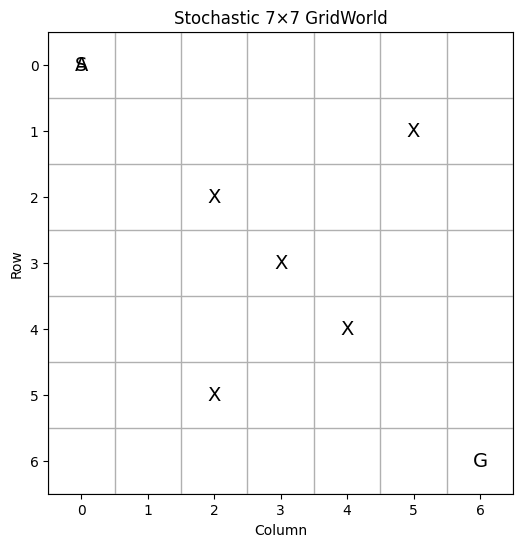

In [3]:
env = StochasticGridworldMDP(seed=SEED)

print("Number of grid cells:", env.size * env.size)
print("Number of obstacle cells:", len(env.obstacles))
print("Number of valid states:", len(env.state_space))
print("Action space:", env.action_space)
print("Start state:", env.start_state)
print("Goal state:", env.goal_state)
print("Intended movement probability:", env.intended_prob)
print("Each slip probability:", env.slip_prob)

env.plot()

## 3. Markov Decision Process

The stochastic environment is still an MDP:

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

but the transition model is now genuinely probabilistic.

For a state–action pair, several next states may have nonzero probability:

$$
P(s'|s,a)\in[0,1],
\qquad
\sum_{s'}P(s'|s,a)=1.
$$

Consider state `(2, 1)` with intended action `Right`.

The intended move goes toward obstacle `(2, 2)`, while the two slip directions are `Up` and `Down`.

In [4]:
example_state = (2, 1)
example_action = "Right"

distribution = env.transition_distribution(example_state, example_action)

print("State:", example_state)
print("Intended action:", example_action)
print()

for probability, next_state, reward, done in distribution:
    print(
        f"P = {probability:.2f} -> "
        f"next_state={next_state}, reward={reward}, done={done}"
    )

print()
print("Probability sum:", sum(item[0] for item in distribution))
print("Expected immediate reward:",
      env.expected_reward(example_state, example_action))

State: (2, 1)
Intended action: Right

P = 0.10 -> next_state=(1, 1), reward=-1, done=False
P = 0.80 -> next_state=(2, 1), reward=-5, done=False
P = 0.10 -> next_state=(3, 1), reward=-1, done=False

Probability sum: 1.0
Expected immediate reward: -4.2


For this state–action pair, the intended movement is blocked by an obstacle, so most probability mass remains in the same state. The two slip outcomes move vertically.

The expected immediate reward is

$$
\mathbb{E}[R_{t+1}\mid s,a]
=
\sum_{s'}P(s'|s,a)R(s,a,s').
$$

The notebook obtains this value from the transition model directly.

### 3.1 A Transition with Three Reachable Next States

Away from boundaries and obstacles, an intended action can lead to three different next states.

In [5]:
state = (4, 1)
action = "Up"

distribution = env.transition_distribution(state, action)

print("State:", state)
print("Intended action:", action)
print()

for probability, next_state, reward, done in distribution:
    print(
        f"P = {probability:.2f} -> "
        f"next_state={next_state}, reward={reward}, done={done}"
    )

print()
print("Probability sum:", sum(item[0] for item in distribution))

State: (4, 1)
Intended action: Up

P = 0.80 -> next_state=(3, 1), reward=-1, done=False
P = 0.10 -> next_state=(4, 0), reward=-1, done=False
P = 0.10 -> next_state=(4, 2), reward=-1, done=False

Probability sum: 1.0


## 4. The Markov Property in a Stochastic Environment

The Markov property does **not** mean that the next state must be deterministic.

It means that the probability distribution of the next state depends on the current state and action rather than the full history:

$$
P(S_{t+1}\mid S_t,A_t,S_{t-1},A_{t-1},\ldots)
=
P(S_{t+1}\mid S_t,A_t).
$$

For the same current state and action, individual samples may differ, but they are drawn from the same transition distribution.

In [19]:
state = (4, 1)
action = "Up"
expected_distribution = env.transition_distribution(state, action)

print("Theoretical transition distribution:")
for probability, next_state, reward, done in expected_distribution:
    print(f"  {next_state}: P={probability:.2f}, reward={reward}")

print()

counts = Counter()
trials = 5000

env.reset(state, seed=SEED)

for _ in range(trials):
    env.state = state
    next_state, reward, done, info = env.step(action)
    counts[(next_state, reward)] += 1

print(f"Empirical frequencies from {trials:,} samples:")
for (next_state, reward), count in sorted(counts.items()):
    print(
        f"  {next_state}, reward={reward}: "
        f"{count / trials:.3f}"
    )

Theoretical transition distribution:
  (3, 1): P=0.80, reward=-1
  (4, 0): P=0.10, reward=-1
  (4, 2): P=0.10, reward=-1

Empirical frequencies from 5,000 samples:
  (3, 1), reward=-1: 0.803
  (4, 0), reward=-1: 0.098
  (4, 2), reward=-1: 0.099


As the number of samples increases, the empirical frequencies approach the probabilities specified by the model.

Random outcomes therefore do not violate the Markov property. The same state–action pair continues to use the same probability distribution.

## 5. Agent–Environment Interaction Under Uncertainty

At each step:

1. The agent observes $S_t$.
2. The agent selects intended action $A_t$.
3. The environment samples a transition from $P(s'|s,a)$.
4. The agent receives $R_{t+1}$.
5. The environment moves to $S_{t+1}$.

Even if the agent repeatedly chooses the same action, the resulting next state can differ because the environment is stochastic.

In [7]:
def random_policy(env):
    return np.random.choice(env.action_space)

env.reset(seed=SEED)
trajectory = []

for step_number in range(1, 13):
    state = env.state
    action = random_policy(env)
    next_state, reward, done, info = env.step(action)

    trajectory.append(
        (step_number, state, action, reward, next_state, info["sampled_outcome_probability"], done)
    )

    if done:
        break

print(
    f"{'Step':<6}{'State':<12}{'Action':<8}{'Reward':<9}"
    f"{'Next State':<12}{'Sample P':<10}{'Done'}"
)

for row in trajectory:
    step_number, state, action, reward, next_state, sample_p, done = row
    print(
        f"{step_number:<6}{str(state):<12}{action:<8}{reward:<9}"
        f"{str(next_state):<12}{sample_p:<10.2f}{done}"
    )

Step  State       Action  Reward   Next State  Sample P  Done
1     (0, 0)      Left    -1       (0, 0)      0.90      False
2     (0, 0)      Right   -1       (0, 1)      0.80      False
3     (0, 1)      Up      -1       (0, 1)      0.80      False
4     (0, 1)      Left    -1       (0, 0)      0.80      False
5     (0, 0)      Left    -1       (0, 0)      0.90      False
6     (0, 0)      Right   -1       (1, 0)      0.10      False
7     (1, 0)      Up      -1       (0, 0)      0.80      False
8     (0, 0)      Up      -1       (0, 0)      0.90      False
9     (0, 0)      Left    -1       (0, 0)      0.90      False
10    (0, 0)      Down    -1       (1, 0)      0.80      False
11    (1, 0)      Left    -1       (1, 0)      0.80      False
12    (1, 0)      Left    -1       (2, 0)      0.10      False


## 6. Policy vs. Environment Stochasticity

These are two different sources of randomness.

### Stochastic environment

The agent chooses an action, but the environment may produce different next states:

$$
P(s'|s,a).
$$

### Stochastic policy

The agent itself randomizes over actions:

$$
\pi(a|s).
$$

A deterministic policy can therefore operate inside a stochastic environment, and a stochastic policy can operate inside either a deterministic or stochastic environment.

In [8]:
def uniform_random_policy(env, state):
    return {action: 1.0 / len(env.action_space) for action in env.action_space}

def simple_deterministic_policy(env, state):
    if state == env.goal_state:
        return None
    if state[0] < env.goal_state[0]:
        return "Down"
    return "Right"

sample_state = (4, 1)

print("State:", sample_state)
print("Uniform random policy:", uniform_random_policy(env, sample_state))
print("Deterministic policy action:", simple_deterministic_policy(env, sample_state))
print()
print("Environment transition distribution if deterministic policy chooses Down:")

for probability, next_state, reward, done in env.transition_distribution(
    sample_state,
    simple_deterministic_policy(env, sample_state)
):
    print(
        f"  P={probability:.2f} -> "
        f"{next_state}, reward={reward}, done={done}"
    )

State: (4, 1)
Uniform random policy: {'Up': 0.25, 'Down': 0.25, 'Left': 0.25, 'Right': 0.25}
Deterministic policy action: Down

Environment transition distribution if deterministic policy chooses Down:
  P=0.10 -> (4, 0), reward=-1, done=False
  P=0.10 -> (4, 2), reward=-1, done=False
  P=0.80 -> (5, 1), reward=-1, done=False


## 7. Return and Discount Factor

The return is still

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots.
$$

The difference is that a stochastic environment can produce different reward sequences from the same intended action sequence.

The following trajectory is sampled directly from the model using a fixed seed.

In [9]:
def run_stochastic_action_sequence(env, start_state, actions, seed):
    env.reset(start_state, seed=seed)

    rows = []

    for action in actions:
        state = env.state
        next_state, reward, done, info = env.step(action)
        rows.append((state, action, next_state, reward, done))

        if done:
            break

    return rows

actions = ["Down", "Down", "Down", "Right", "Down", "Right"]
sampled_path = run_stochastic_action_sequence(
    env,
    start_state=(3, 5),
    actions=actions,
    seed=7
)

sampled_rewards = [row[3] for row in sampled_path]

for state, action, next_state, reward, done in sampled_path:
    print(
        f"{state} --{action}--> {next_state}, "
        f"reward={reward}, done={done}"
    )

print()
print("Rewards generated by the stochastic model:", sampled_rewards)

(3, 5) --Down--> (4, 5), reward=-1, done=False
(4, 5) --Down--> (5, 5), reward=-1, done=False
(5, 5) --Down--> (6, 5), reward=-1, done=False
(6, 5) --Right--> (6, 6), reward=10, done=True

Rewards generated by the stochastic model: [-1, -1, -1, 10]


In [10]:
def discounted_return(rewards, gamma):
    return sum((gamma ** t) * reward for t, reward in enumerate(rewards))

for gamma in [0.0, 0.5, 0.9, 1.0]:
    value = discounted_return(sampled_rewards, gamma)
    print(f"gamma = {gamma:>3}: G = {value:.3f}")

gamma = 0.0: G = -1.000
gamma = 0.5: G = -0.500
gamma = 0.9: G = 4.580
gamma = 1.0: G = 7.000


The return is calculated from the rewards that actually occurred in the sampled trajectory. Under another random seed, the same intended action sequence may produce a different trajectory and therefore a different realized return.

## 8. State-Value Function \(V^\pi(s)\)

For a stochastic environment,

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s].
$$

The expectation now averages over both:

1. actions selected by the policy, and
2. stochastic next states generated by the environment.

For a fixed policy,

$$
V^\pi(s)
=
\sum_a \pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right].
$$

The following code evaluates the **uniform random policy** using the complete transition distribution.

In [11]:
def evaluate_uniform_random_policy(env, gamma=0.9, tolerance=1e-10, max_iterations=10000):
    values = {state: 0.0 for state in env.state_space}
    action_probability = 1.0 / len(env.action_space)

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in env.state_space:
            if state == env.goal_state:
                new_values[state] = 0.0
                continue

            state_value = 0.0

            for action in env.action_space:
                action_value = 0.0

                for probability, next_state, reward, done in env.transition_distribution(state, action):
                    future_value = 0.0 if done else values[next_state]
                    action_value += probability * (
                        reward + gamma * future_value
                    )

                state_value += action_probability * action_value

            new_values[state] = state_value
            delta = max(delta, abs(state_value - values[state]))

        values = new_values

        if delta < tolerance:
            return values, iteration

    raise RuntimeError("Policy evaluation did not converge.")

V_random, sweeps = evaluate_uniform_random_policy(env, gamma=0.9)

print("Policy-evaluation sweeps:", sweeps)
print(f"V^pi(0, 0) = {V_random[(0, 0)]:.3f}")
print(f"V^pi(2, 1) = {V_random[(2, 1)]:.3f}")
print(f"V^pi(5, 6) = {V_random[(5, 6)]:.3f}")
print(f"V^pi(6, 5) = {V_random[(6, 5)]:.3f}")
print(f"V^pi(6, 6) = {V_random[(6, 6)]:.3f}")

Policy-evaluation sweeps: 216
V^pi(0, 0) = -11.787
V^pi(2, 1) = -14.243
V^pi(5, 6) = -2.263
V^pi(6, 5) = -2.399
V^pi(6, 6) = 0.000


### 8.1 Visualize the State Values

The values below are expected long-term returns under the same uniform random policy while accounting for uncertain transitions.

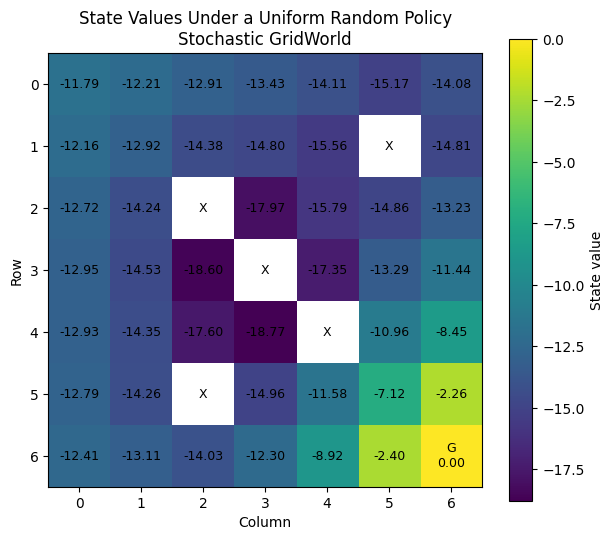

In [12]:
def plot_state_values(env, values, title):
    value_grid = np.full((env.size, env.size), np.nan)

    for state, value in values.items():
        value_grid[state] = value

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(value_grid)

    for row in range(env.size):
        for col in range(env.size):
            state = (row, col)

            if state in env.obstacles:
                label = "X"
            elif state == env.goal_state:
                label = "G\n0.00"
            else:
                label = f"{values[state]:.2f}"

            ax.text(col, row, label, ha="center", va="center", fontsize=9)

    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="State value")
    plt.show()

plot_state_values(
    env,
    V_random,
    "State Values Under a Uniform Random Policy\nStochastic GridWorld"
)

## 9. Action-Value Function \(Q^\pi(s,a)\)

For a stochastic MDP,

$$
Q^\pi(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right].
$$

Unlike the deterministic case, $(Q^\pi(s,a)$ generally cannot be obtained from a single next state. Every possible next state must be weighted by its transition probability.

In [13]:
def q_from_state_values(env, values, state, action, gamma=0.9):
    q_value = 0.0
    components = []

    for probability, next_state, reward, done in env.transition_distribution(state, action):
        future_value = 0.0 if done else values[next_state]
        component = probability * (reward + gamma * future_value)
        q_value += component

        components.append(
            {
                "probability": probability,
                "next_state": next_state,
                "reward": reward,
                "future_value": future_value,
                "weighted_component": component,
            }
        )

    return q_value, components

q_demo_state = (5, 6)
q_values = {}

for action in env.action_space:
    q_value, _ = q_from_state_values(
        env,
        V_random,
        q_demo_state,
        action,
        gamma=0.9
    )
    q_values[action] = q_value
    print(f"{action:<5}: Q^pi = {q_value:.3f}")

Up   : Q^pi = -7.929
Down : Q^pi = 6.956
Left : Q^pi = -5.787
Right: Q^pi = -2.290


### 9.1 Expand One Stochastic $(Q^\pi(s,a)$ Calculation

The next cell prints every probability-weighted term used for one action.

In [14]:
state = (5, 6)
action = "Down"

q_value, components = q_from_state_values(
    env,
    V_random,
    state,
    action,
    gamma=0.9
)

print("State:", state)
print("Intended action:", action)
print()

for item in components:
    print(
        f"P={item['probability']:.2f}, "
        f"next_state={item['next_state']}, "
        f"reward={item['reward']}, "
        f"V(next)={item['future_value']:.3f}, "
        f"weighted term={item['weighted_component']:.3f}"
    )

print()
print(f"Q^pi({state}, {action}) = {q_value:.6f}")

State: (5, 6)
Intended action: Down

P=0.10, next_state=(5, 5), reward=-1, V(next)=-7.121, weighted term=-0.741
P=0.10, next_state=(5, 6), reward=-1, V(next)=-2.263, weighted term=-0.304
P=0.80, next_state=(6, 6), reward=10, V(next)=0.000, weighted term=8.000

Q^pi((5, 6), Down) = 6.955517


This calculation makes the role of transition uncertainty explicit. Even when the intended action points toward the goal, slip outcomes must still be included in the expectation.

## 10. Bellman Expectation Equation

The Bellman expectation equation is

$$
V^\pi(s)
=
\sum_a \pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right].
$$

This is the full form of the equation. The outer sum averages over policy actions, while the inner sum averages over stochastic environment outcomes.

The next calculation verifies the equation numerically at `(5, 6)`.

In [15]:
state = (5, 6)
policy = uniform_random_policy(env, state)
weighted_action_terms = {}

for action, action_probability in policy.items():
    q_value, _ = q_from_state_values(
        env,
        V_random,
        state,
        action,
        gamma=0.9
    )
    weighted_action_terms[action] = action_probability * q_value

bellman_rhs = sum(weighted_action_terms.values())
stored_value = V_random[state]

for action in env.action_space:
    print(
        f"{action:<5}: "
        f"pi(a|s)={policy[action]:.2f}, "
        f"Q^pi={q_values[action]:.3f}, "
        f"weighted={weighted_action_terms[action]:.3f}"
    )

print()
print(f"Bellman RHS = {bellman_rhs:.6f}")
print(f"Stored V^pi = {stored_value:.6f}")
print(f"Absolute difference = {abs(bellman_rhs - stored_value):.12f}")

Up   : pi(a|s)=0.25, Q^pi=-7.929, weighted=-1.982
Down : pi(a|s)=0.25, Q^pi=6.956, weighted=1.739
Left : pi(a|s)=0.25, Q^pi=-5.787, weighted=-1.447
Right: pi(a|s)=0.25, Q^pi=-2.290, weighted=-0.572

Bellman RHS = -2.262615
Stored V^pi = -2.262615
Absolute difference = 0.000000000026


The numerical difference should be essentially zero, confirming

$$
V^\pi(s)
=
\sum_a\pi(a|s)Q^\pi(s,a)
$$

for the stochastic GridWorld.

## 11. Bellman Optimality Equation

The Bellman optimality equation is

$$
V^*(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right].
$$

The key difference from the deterministic case is that each action must first be evaluated over **all possible transition outcomes**.

The following cell performs one `max` backup using the already evaluated state values as the future-value reference. It demonstrates the mechanism without solving the full optimal-control problem.

In [16]:
best_action = max(q_values, key=q_values.get)
best_value = q_values[best_action]

print("State:", q_demo_state)
print("Expected action values:")

for action, value in q_values.items():
    print(f"  {action:<5}: {value:.3f}")

print()
print("Action selected by max operator:", best_action)
print(f"Maximum expected backed-up value: {best_value:.3f}")

State: (5, 6)
Expected action values:
  Up   : -7.929
  Down : 6.956
  Left : -5.787
  Right: -2.290

Action selected by max operator: Down
Maximum expected backed-up value: 6.956


In a stochastic environment, the action with the best expected value is chosen. That action may still fail to produce its most desirable transition on any individual step.

Repeated optimality backups over all states lead to planning methods such as value iteration.

## 12. Exploration vs. Environmental Randomness

These concepts should not be confused.

### Environmental stochasticity

Even if the agent always chooses the same action, the environment can return different next states.

### Exploration

The agent deliberately chooses actions that are not currently greedy.

A common exploration rule is $\epsilon$-greedy:

$$
\pi_\epsilon(a|s)=
\begin{cases}
1-\epsilon+\frac{\epsilon}{|\mathcal{A}|}, & a=a^* \\
\frac{\epsilon}{|\mathcal{A}|}, & a\neq a^*
\end{cases}
$$

where $a^*$ is the action with the largest current action value.

Therefore, two different probability mechanisms may operate at once:

1. the agent randomizes over actions,
2. the environment randomizes over next states.

In [17]:
def epsilon_greedy_action(action_values, epsilon=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    actions = list(action_values.keys())

    if rng.random() < epsilon:
        return rng.choice(actions)

    return max(action_values, key=action_values.get)

rng = np.random.default_rng(SEED)
epsilon = 0.1
samples = 1000

selection_counts = Counter(
    epsilon_greedy_action(q_values, epsilon=epsilon, rng=rng)
    for _ in range(samples)
)

print("State:", q_demo_state)
print("Greedy action based on expected Q-values:", best_action)
print("epsilon:", epsilon)
print("Agent action selections from 1,000 decisions:")

for action in env.action_space:
    count = selection_counts[action]
    print(f"  {action:<5}: {count:>4} ({count / samples:.1%})")

State: (5, 6)
Greedy action based on expected Q-values: Down
epsilon: 0.1
Agent action selections from 1,000 decisions:
  Up   :   29 (2.9%)
  Down :  935 (93.5%)
  Left :   21 (2.1%)
  Right:   15 (1.5%)


### 12.1 What Happens After the Greedy Action Is Selected?

The agent may select the greedy intended action, but the environment still samples an outcome from its transition distribution.

In [18]:
print("Greedy intended action:", best_action)
print("Possible environment outcomes:")

for probability, next_state, reward, done in env.transition_distribution(
    q_demo_state,
    best_action
):
    print(
        f"  P={probability:.2f} -> "
        f"next_state={next_state}, reward={reward}, done={done}"
    )

Greedy intended action: Down
Possible environment outcomes:
  P=0.10 -> next_state=(5, 5), reward=-1, done=False
  P=0.10 -> next_state=(5, 6), reward=-1, done=False
  P=0.80 -> next_state=(6, 6), reward=10, done=True


## 13. Foundation Summary

The stochastic GridWorld is described by

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma).
$$

The major quantities are

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots
$$

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s]
$$

and

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a].
$$

For stochastic transitions,

$$
Q^\pi(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right].
$$

The Bellman expectation equation averages over both policy decisions and environment outcomes:

$$
V^\pi(s)
=
\sum_a\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right].
$$

The Bellman optimality equation replaces the policy-weighted action average with the best expected action value.

The central distinction is:

- **policy uncertainty** concerns which action the agent chooses,
- **transition uncertainty** concerns what happens after that action is chosen.

These ideas provide the mathematical basis for reinforcement-learning methods that operate in uncertain environments.